# **Ovarian Reserve - Training workflow**
___

This notebook trains a **3D instance segmentation** workflow in **BiaPy** for ovarian oocytes, following the [ovarian reserve tutorial from the BiaPy documentation](https://biapy.readthedocs.io/en/latest/tutorials/instance_seg/ovarian-reserve.html).

- Training data: our sample dataset (`oocyte_training.zip`).
- Colab-friendly testing in this notebook: the validation (`val/`) folder is used as test input (the Zenodo test set is too large for typical Colab sessions).

<figure>
<center>
<img src='https://raw.githubusercontent.com/BiaPyX/BiaPy-doc/refs/heads/master/source/img/tutorials/instance-segmentation/ovarian-reserve/F1.large.jpg' width='500'/>
<figcaption>Paper Figure 1: SPIM whole-ovary imaging and model-based oocyte segmentation workflow.</figcaption>
</center>
</figure>

___

If this workflow is useful for your research, please cite:

*3D Mapping of Intact Ovaries Reveals the Aging Dynamics of the Ovarian Reserve*  
Arturo D'Angelo, Daniel Franco-Barranco, Marco Musy, James Sharpe, Ignacio Arganda-Carreras, Elvan Böke  
bioRxiv 2025.11.07.686728; doi: https://doi.org/10.1101/2025.11.07.686728

## **Expected Inputs and Outputs**
___

### **Inputs**
This notebook needs five input folders:
- **Training Raw Images**: Containing the raw 3D images for training the model. (`oocyte_training/train/raw` in our sample dataset).
- **Training Label Images**: These should have instance-label 3D images for training. Their quantity and dimensions should align with the training raw images (`oocyte_training/train/label` in our sample dataset)
- **Validation Raw Images**: Containing the raw 3D images for model validation (`oocyte_training/val/raw` in our sample dataset).
- **Validation Label Images**: Containing instance-label 3D images for validation. Their quantity and dimensions should match those of the validation raw images (`oocyte_training/val/label` in our sample dataset).
- **Output Folder**

### **Outputs**
If the execution is successful, BiaPy creates experiment folders with config files, checkpoints, logs, and prediction outputs.

<figure>
<center>
<img src='https://raw.githubusercontent.com/BiaPyX/BiaPy-doc/refs/heads/master/source/img/tutorials/instance-segmentation/ovarian-reserve/oocyte_train_sample.gif' width='500'/>
<figcaption><b>Example training pair</b>: raw DDX4 stack (left) and instance label stack (right).</figcaption>
</center>
</figure>

**Data structure**

To ensure the proper operation of the library, the input data directory tree should be something like this:
```
dataset/
├── train
│   ├── x
│   │   ├── training-0001.tif
│   │   ├── training-0002.tif
│   │   ├── . . .
│   │   └── training-9999.tif
│   └── y
│       ├── training-0001.tif
│       ├── training-0002.tif
│       ├── . . .
│       └── training-9999.tif
└── validation
    ├── x
    │   ├── validation-0001.tif
    │   ├── validation-0002.tif
    │   ├── . . .
    │   └── validation-9999.tif
    └── y
        ├── validation-0001.tif
        ├── validation-0002.tif
        ├── . . .
        └── validation-9999.tif
```
**⚠️ Warning:** Ensure that images and their corresponding masks are sorted in the same way. A common approach is to fill with zeros the image number added to the filenames (as in the example).

**Input Format Support**

This notebook is compatible with a range of input formats. You can use the following file extensions: `.tif`, `.npy` (every extension for 3D images supported by [scikit-image](https://scikit-image.org/docs/stable/api/skimage.io.html#skimage.io.imread)).

## **Prepare the environment**
___

Establish connection with Google services. You **must be logged in to Google** to continue.
Since this is not Google's own code, you will probably see a message warning you of the dangers of running unfamiliar code. This is completely normal.

## **Check for GPU Access**
---

By default, the session is configured to use Python 3 with GPU acceleration. However, it's a good practice to double-check these settings:

1. Navigate to **Runtime** in the top menu and select **Change the Runtime type**.
2. Ensure the following settings:
   - **Runtime type:** Python 3 (This program is written in the Python 3 programming language.)
   - **Accelerator:** GPU (Graphics Processing Unit)

This will ensure that you're using Python 3 and taking advantage of GPU acceleration.


## **Install BiaPy**
---
This might take some minutes depending on the current installed libraries in Colab.


In [1]:
#@markdown ##Play to install BiaPy and its dependences
# Install latest release of BiaPy
!pip install biapy==3.6.8

# Then install Pytorch
!pip install torch==2.9.1 torchvision

# Finally install some packages that rely on the Pytorch installation
!pip install timm==1.0.14 pytorch-msssim torchmetrics[image]==1.4.*

import os
import sys
import numpy as np
from tqdm.notebook import tqdm
from skimage.io import imread
import ipywidgets as widgets
from ipywidgets import Output
from biapy import BiaPy

changed_source = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.7/594.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.7/174.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.3/210.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.6 MB/s eta 0:00:00
   ━━━━

## **Manage File(s) Source**
---
You can provide input data with one of these options:
1. **Direct Upload** to Colab
2. **Google Drive** mounted folder
3. **Sample Data** downloaded from the ovarian reserve Google Drive link

### **Option 1: Upload Files from Your Local Machine**
---
Use these cells to upload your own TIFF files into `/content/oocyte_training/raw` and `/content/oocyte_training/label`.

In [ ]:
#@title ## Play to upload local files (training raw images)
from google.colab import files
!mkdir -p /content/oocyte_training/raw
%cd /content/oocyte_training/raw
uploaded = files.upload()
%cd /content

In [ ]:
#@title ## Play to upload local files (training label images)
from google.colab import files
!mkdir -p /content/oocyte_training/label
%cd /content/oocyte_training/label
uploaded = files.upload()
%cd /content

### **Option 2: Mount Your Google Drive**
---
Mount your drive if your dataset is already there.

In [ ]:
#@markdown ##Play the cell to connect your Google Drive to Colab

#@markdown * Click on the URL.

#@markdown * Sign in your Google Account.

#@markdown * Copy the authorization code.

#@markdown * Enter the authorization code.

#@markdown * Click on "Files" site on the right. Refresh the site. Your Google Drive folder should now be available here as "drive".

# mount user's Google Drive to Google Colab.
from google.colab import drive
drive.mount('/content/gdrive')

### **Option 3: Download the Ovarian Reserve Example Dataset**
---
This downloads `oocyte_training.zip` from Google Drive and unzips it in `/content/oocyte_training`.

In [8]:
#@title ## Play to download the example ovarian reserve training dataset
os.chdir('/content')
dataset_zip = 'oocyte_training.zip'
dataset_dir = '/content/oocyte_training'

print( 'Downloading example training dataset...')

if not os.path.exists(dataset_zip) and not os.path.exists(dataset_dir):
    !wget -q -O oocyte_training.zip 'https://upvehueus-my.sharepoint.com/:u:/g/personal/ignacio_arganda_ehu_eus/IQBlTg1-y8MlSqwgDpLZuPAgAU5oE0HOqc6vjDK7vVh_xBM?e=MMgzZf&download=1'

if os.path.exists(dataset_zip) and not os.path.exists(dataset_dir):
    !unzip -q oocyte_training.zip

print('Dataset ready at:', dataset_dir)
# !ls -la /content/oocyte_training | head

Dataset ready at: /content/oocyte_training


## **Paths for Input Images and Output Files**
___

Depending on the option you chose for managing file sources, you'll set your paths differently:

- **Option 1 (Upload from Local Machine)**:
  - Set `train_data_path` to `/content/input/train/raw`
  - Set `train_data_gt_path` to `/content/input/train/label`
  - Set `val_data_path` to `/content/input/val/raw`
  - Set `val_data_gt_path` to `/content/input/val/label`
  - Set `output_path` to `/content/out`
  
- **Option 2 (Use Google Drive Data)**:
  - Insert the paths to your input files and your desired output directory here, i.e., `/content/gdrive/MyDrive/...`.
  
- **Option 3 (Use Our Sample Data)**:
  - Set `train_data_path` to `/content/oocyte_training/train/raw`
  - Set `train_data_gt_path` to `/content/oocyte_training/train/label`
  - Set `val_data_path` to `/content/oocyte_training/val/raw`
  - Set `val_data_gt_path` to `/content/oocyte_training/val/label`
  - Set `output_path` to `/content/out`

  **Note**: Ensure you download your results from the `/content/out` directory after the process!

**Helpful Tip**: If you're unsure about the paths to your folders, look at the top left of this notebook for a small folder icon. Navigate through the directories until you locate your desired folder. Right-click on it and select "Copy Path" to copy the folder's path.

In [9]:
#@markdown #####Path to train raw images
train_data_path = '/content/oocyte_training/train/raw' #@param {type:"string"}
#@markdown #####Path to train label images
train_data_gt_path = '/content/oocyte_training/train/label' #@param {type:"string"}
#@markdown #####Path to validation images
val_data_path = '/content/oocyte_training/val/raw' #@param {type:"string"}
#@markdown #####Path to validation instances
val_data_gt_path = '/content/oocyte_training/val/label' #@param {type:"string"}
#@markdown #####Path to store the resulting images (it'll be created if not existing):
output_path = '/content/output' #@param {type:"string"}

import os
from pathlib import Path

def count_image_files(directory):
    if not directory or not os.path.exists(directory):
        return 0
    image_extensions = {'.jpg', '.jpeg', '.png', '.tif', '.npy', '.tiff', '.h5', '.hd5', '.zarr'}
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if Path(file).suffix.lower() in image_extensions:
                count += 1
    return count

num_train_images = count_image_files(train_data_path)
num_train_labels = count_image_files(train_data_gt_path)

print(f"Number of training raw images: {num_train_images}")
print(f"Number of training label images: {num_train_labels}")

if num_train_images != num_train_labels:
    print("Error: The number of training raw images does not match the number of training label images.")

num_val_images = count_image_files(val_data_path)
num_val_labels = count_image_files(val_data_gt_path)

print(f"Number of validation raw images: {num_val_images}")
print(f"Number of validation label images: {num_val_labels}")

if num_val_images != num_val_labels:
    print("Error: The number of validation raw images does not match the number of validation label images.")



Number of training raw images: 66
Number of training label images: 66
Number of validation raw images: 7
Number of validation label images: 7


## **Dataset Visualization**
---

In [15]:
# @markdown ## Play to visualize some data samples
# @markdown Select the *Set* (training or validation) to visualize samples from, and use the *Image index* and *Z value* scrolls to navigate among volumes and slices. **Note**: it might take a few seconds to refresh the images.
%matplotlib inline
import matplotlib
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
import os
from ipywidgets import interact, IntSlider, Layout, Dropdown, VBox, Output

# Initialize global attributes
input_path = train_data_path
gt_path = train_data_gt_path

instance_id = 0

ids_input_all = sorted(next(os.walk(input_path))[2])
ids_input = [f for f in ids_input_all if f.endswith('.tif')]
input_img = imread(os.path.join(input_path, ids_input[0]))

ids_gt_all = sorted(next(os.walk(gt_path))[2])
ids_gt = [f for f in ids_gt_all if f.endswith('.tif')]
gt_img = imread(os.path.join(gt_path, ids_gt[0])).astype(np.uint16)

# Create random color map
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.] # set background to black

# Initialize widgets

# Dropdown widget to choose training or test validation
dropdown = Dropdown(
    options=['training-set', 'validation-set'],
    value='training-set',
    description='Set:',
    disabled=False,
)

# Slider widget to choose instance
slider= IntSlider(
    value=0,
    min=1,
    max=len(ids_input),
    step=1,
    description='Image index:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    layout=Layout(width='500px', margin = '0 0 0 10px')
)

slider.style.description_width = 'initial'
slider.style.handle_color='blue'

# Slider widget to choose Z value
sliderZ= IntSlider(
    value=0,
    min=1,
    max=len(input_img),
    step=1,
    description='Z value:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    layout=Layout(width='500px', margin = '0 0 0 10px')
)

sliderZ.style.description_width = 'initial'
sliderZ.style.handle_color='blue'

# Initialize Output instance to handle code output cell
output = Output()

# Function to update paths (input_path, gt_path) and image IDs (ids_input, ids_gt) depending on dropdown
def update_paths(change):
    global input_path, gt_path
    if change.new == 'validation-set':
        input_path = val_data_path
        gt_path = val_data_gt_path
    else:
        input_path = train_data_path
        gt_path = train_data_gt_path

    global ids_input, ids_gt
    ids_input_all = sorted(next(os.walk(input_path))[2])
    ids_input = [f for f in ids_input_all if f.endswith('.tif')]
    try:
        ids_gt_all = sorted(next(os.walk(gt_path))[2])
        ids_gt = [f for f in ids_gt_all if f.endswith('.tif')]
    except StopIteration:
        ids_gt = []

    # Reset slider value to 1 when dropdown changes
    slider.value = 1
    slider.max = len(ids_input)
    update_id({'new': 1})

# Function to update image and label set (input_img, gt_img, instance_id) depending on slider value
def update_id(change):
    index = change['new']

    global instance_id
    instance_id = index - 1

    global input_path, ids_input, input_img, gt_path, ids_gt, gt_img
    input_img_path = os.path.join(input_path, ids_input[instance_id])
    input_img = imread(input_img_path)

    if ids_gt != []: # If StopIteration exception was not thrown
        gt_img_path = os.path.join(gt_path, ids_gt[instance_id])
        gt_img = imread(gt_img_path).astype(np.uint16)
    else:
        gt_img = None

    sliderZ.value = 1
    sliderZ.max = len(input_img)
    display_images({'new': 1})

# Function to display images depending on sliderZ value
def display_images(change):
    with output:
        output.clear_output(wait=True)
        index = change['new']

        global input_img, gt_img, instance_id

        # Display images
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title(f"Input image: {instance_id+1}, Z: {index}")
        plt.imshow(input_img[index-1], cmap='gray')
        # plt.axis('off')

        # # # Print sample path to ensure the image displayed is correct
        # global input_path, ids_input
        # print(os.path.join(input_path, ids_input[instance_id]))

        if gt_img is not None:
            plt.subplot(1, 2, 2)
            plt.title("Label")
            plt.imshow(gt_img[index-1], cmap=cmap, interpolation='nearest')
            # plt.axis('off')

            # # # Print label path to ensure the image displayed is correct
            # global gt_path, ids_gt
            # print(os.path.join(gt_path, ids_gt[instance_id]))

        else:
            print("No labels for this set.")

        plt.show()


# Create an VBox to hold the dropdown and slider
controls = VBox([dropdown, slider, sliderZ])
display(controls, output)

# Link widgets to functions
dropdown.observe(update_paths, names='value')
slider.observe(update_id, names='value')
sliderZ.observe(display_images, names='value')

# Initial display
display_images({'new': slider.value})

Output()

## **Train the model**
----
Next, we will train the model using all the training samples and will stop if the results are improving on set-aside validation samples.



### **Select your parameters**
---

In the original publication, the training of the model was performed 800 epochs and using 100 as patience (with a reduce-on-plateau learning rate scheduler). Since those values involve several hours of training, **here we propose another parameter setting** to obtain preliminary results faster (~120 minutes).

#### **Basic training parameters**
* **`number_of_epochs`:** Input how many epochs (rounds) the network will be trained. **Default value: 100** (Publication value: 800).

* **`patience`:**  Input how many epochs you want to wait without the model improving its results in the validation set to stop training. **Default value: 20** (Publication value: 100).

#### **Advanced Parameters - experienced users only**

* **`batch_size:`** This parameter defines the number of patches seen in each training step. Reducing or increasing the **batch size** may slow or speed up your training, respectively, and can influence network performance. **Default value: 4** (Publication value: 4).

* **`patch_size_xy`:** Input the XY size of the patches use to train your model (length in pixels in X and Y). The value should be smaller or equal to the dimensions of the image. **Default value: 128** (Publication value: 128).

* **`patch_size_z`:** Input the Z size of the patches use to train your model (length in pixels in Z). The value should be smaller or equal to the dimensions of the image. **Default value: 40** (Publication value: 40).

* **`optimizer`:** Select the optimizer used to train your model. Options: ADAM, ADAMW, Stochastic Gradient Descent (SGD). ADAM usually converges faster, while ADAMW provides a balance between fast convergence and better handling of weight decay regularization. SGD is known for better generalization. **Default value: ADAMW** (Publication value: ADAMW).

* **`initial_learning_rate`:** Input the initial value to be used as learning rate. This value is taken as the maximum learning rate value when you select a "One cycle" scheduler (see below). **Default value: 0.001** (Publication value: 0.0001).

* **`learning_rate_scheduler`:** Select to adjust the learning rate between epochs. Options: "None", "Reduce on plateau", "One cycle", "Warm-up cosine decay". **Default value: Warm-up cosine decay** (Publication value: "Reduce on plateau").

In [10]:
#@markdown ### Basic training parameters:
number_of_epochs =  100#@param {type:"number"}
patience =  20#@param {type:"number"}

#@markdown ### Advanced training parameters:

batch_size =  4 #@param {type:"number"}
patch_size_xy = 128 #@param {type:"number"}
patch_size_z = 40 #@param {type:"number"}

optimizer = "ADAMW" #@param ["ADAM", "SGD","ADAMW"]
initial_learning_rate = 0.0001 #@param {type:"number"}
learning_rate_scheduler = "Warm-up cosine decay" #@param ["None", "Reduce on plateau","One cycle", "Warm-up cosine decay"]

checkpoint_path = ''

In [ ]:
#@markdown ##OPTIONAL: Play the cell to upload initial model weights
#@markdown Use this option to start the training from a **pre-trained model** if you have one. Otherwise, skip this cell. You can download an already trained model using the paper's default parameters from our [official repository](https://upvehueus-my.sharepoint.com/:u:/g/personal/ignacio_arganda_ehu_eus/IQBqhycRQT1zTakayPKsyJLqAXzibIJSV_xIKADXYnLP3zM?e=UqJEo9&download=1).

#@markdown **Important**: remember the weights must correspond to the selected architecture, patch size and number of input channels. Otherwise, an error will be shown when training.
from google.colab import files

#os.chdir('/content/')

uploaded = files.upload()

checkpoint_path = '/content/' + list(uploaded.keys())[0]

# open previously configured file, if exists
job_name = "ovarian_reserve_training"
yaml_file = "/content/"+str(job_name)+".yaml"

# edit previous configuration file if it exists to load the checkpoint model
if os.path.exists( yaml_file ):
    import yaml
    with open( yaml_file, 'r') as stream:
        try:
            biapy_config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    biapy_config['PATHS'] = {}
    biapy_config['PATHS']['CHECKPOINT_FILE'] = checkpoint_path
    biapy_config['MODEL'] = {}
    biapy_config['MODEL']['LOAD_CHECKPOINT'] = True

    # save file
    with open( yaml_file, 'w') as outfile:
        yaml.dump(biapy_config, outfile, default_flow_style=False)

print( "Pre-trained model loaded and ready to re-train.")

### **Train the model**
---

In [17]:
#@markdown ##Play to train the model

import os
import errno

os.chdir('/content/')

job_name = "ovarian_reserve_training"
input_channels = 1

yaml_file = "/content/"+str(job_name)+".yaml"

# remove previous configuration file if it exists with the same name
if os.path.exists( yaml_file ):
    os.remove( yaml_file )

# remove template file it is exists
template_file = 'ovarian_reserve_training.yaml'
if os.path.exists( template_file ):
    os.remove( template_file )

# Download template file
!wget https://raw.githubusercontent.com/BiaPyX/BiaPy/master/templates/instance_segmentation/Ovarian_Reserve_paper/ovarian_reserve_training.yaml &> /dev/null

# Check folders before modifying the .yaml file
if not os.path.exists(train_data_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), train_data_path)
ids = sorted(next(os.walk(train_data_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(train_data_path))
if not os.path.exists(train_data_gt_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), train_data_gt_path)
ids = sorted(next(os.walk(train_data_gt_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(train_data_gt_path))

# Check folders before modifying the .yaml file
if not os.path.exists(val_data_path):
    raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), val_data_path)
ids = sorted(next(os.walk(val_data_path))[2])
if len(ids) == 0:
    raise ValueError("No images found in dir {}".format(val_data_path))


# open template configuration file
import yaml
with open( template_file, 'r') as stream:
    try:
        biapy_config = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

# update paths to data
biapy_config['DATA']['TRAIN']['PATH'] = train_data_path
biapy_config['DATA']['TRAIN']['GT_PATH'] = train_data_gt_path
biapy_config['DATA']['VAL']['FROM_TRAIN'] = False
biapy_config['DATA']['VAL']['PATH'] = val_data_path
biapy_config['DATA']['VAL']['GT_PATH'] = val_data_gt_path
# use validation set as test to show some results
biapy_config['DATA']['TEST']['PATH'] = val_data_path
biapy_config['DATA']['TEST']['GT_PATH'] = val_data_gt_path


# update data patch size
biapy_config['DATA']['PATCH_SIZE'] = '('+str(patch_size_z)+', '+ str(patch_size_xy)+', '+ str(patch_size_xy)+ ', ' + str(input_channels)+')'

# update training parameters
biapy_config['TRAIN']['EPOCHS'] = number_of_epochs
biapy_config['TRAIN']['PATIENCE'] = patience
biapy_config['TRAIN']['BATCH_SIZE'] = batch_size
biapy_config['TRAIN']['OPTIMIZER'] = optimizer
biapy_config['TRAIN']['LR'] = initial_learning_rate

# make sure the plots are created when using few epochs
if number_of_epochs < 10:
    biapy_config['LOG'] = {}
    biapy_config['LOG']['CHART_CREATION_FREQ'] = 1

# learning rate scheduler
if learning_rate_scheduler == 'One cycle':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'onecycle'
elif learning_rate_scheduler == 'Warm-up cosine decay':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'warmupcosine'
    biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 0.0
    biapy_config['TRAIN']['LR_SCHEDULER']['WARMUP_COSINE_DECAY_EPOCHS'] = 0
elif learning_rate_scheduler == 'Reduce on plateau':
    biapy_config['TRAIN']['LR_SCHEDULER'] = {}
    biapy_config['TRAIN']['LR_SCHEDULER']['NAME'] = 'reduceonplateau'
    biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_FACTOR'] = 0.5
    biapy_config['TRAIN']['LR_SCHEDULER']['REDUCEONPLATEAU_PATIENCE'] = 80
    biapy_config['TRAIN']['LR_SCHEDULER']['MIN_LR'] = 1.0e-6

# update test parameters
biapy_config['TEST']['FULL_IMG'] = False
biapy_config['TEST']['BY_CHUNKS']['ENABLE'] = False # Do not use Zarr format during testing in this tutorial
biapy_config['DATA']['TEST']['LOAD_GT'] = True
biapy_config['TEST']['ENABLE'] = True

# model weights
if checkpoint_path != '':
    biapy_config['PATHS'] = {}
    biapy_config['PATHS']['CHECKPOINT_FILE'] = checkpoint_path
    biapy_config['MODEL'] = {}
    biapy_config['MODEL']['LOAD_CHECKPOINT'] = True

biapy_config['AUGMENTOR']['ELASTIC'] = False # prevent OpenCV error

# save file
with open( yaml_file, 'w') as outfile:
    yaml.dump(biapy_config, outfile, default_flow_style=False)

print( "Training configuration finished.")

# Run the code
biapy = BiaPy(f'/content/{job_name}.yaml', result_dir=output_path, name=job_name, run_id=1, gpu=0)
biapy.run_job()

Training configuration finished.
Date     : 2026-03-31 14:37:24
Arguments: Namespace(config='/content/ovarian_reserve_training.yaml', result_dir='/content/output', name='ovarian_reserve_training', run_id=1, gpu=0, world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : ovarian_reserve_training_1
BiaPy    : 3.6.8
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch  : 2.9.1+cu128
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[14:37:24.648331] Configuration details:
[14:37:24.648472] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
  CONTRAST: False
  CONTRAST_FACTOR: (-0.1, 0.1)
  COUT_APPLY

  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|       

[14:37:50.548794] You select to create ['F', 'C', 'Db'] channels from given instance labels and no file is detected in /content/oocyte_training/val/label_F.erosion-0.dilation-0_C.mode-thick_Db.norm-True.mask_values-True . So let's prepare the data. This process will be done just once!
[14:37:50.549521] Creating Y_val channels . . .


  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|          | 0/1 [00:00<?, ?it/s]
                                     
  0%|       

[14:37:53.099996] DATA.TRAIN.GT_PATH changed from /content/oocyte_training/train/label to /content/oocyte_training/train/label_F.erosion-0.dilation-0_C.mode-thick_Db.norm-True.mask_values-True
[14:37:53.100118] DATA.VAL.GT_PATH changed from /content/oocyte_training/val/label to /content/oocyte_training/val/label_F.erosion-0.dilation-0_C.mode-thick_Db.norm-True.mask_values-True
[14:37:53.100172] DATA.TEST.GT_PATH changed from /content/oocyte_training/val/label to /content/oocyte_training/val/label_F.erosion-0.dilation-0_C.mode-thick_Db.norm-True.mask_values-True
[14:37:53.100855] ##########################
[14:37:53.100933] #   LOAD TRAINING DATA   #
[14:37:53.100980] ##########################
[14:37:53.101082] ### LOAD ###
[14:37:53.101791] Gathering raw images for training data . . .
[14:37:54.005977] Gathering labels for training data . . .
[14:37:58.007709] Checking training raw and label images' shapes . . .
[14:37:58.008557] Gathering raw images for validation data . . .
[14:37:5

...

[16:40:12.121253] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': 0, 'tp': 8, 'fn': 0, 'precision': 1.0, 'recall': 1.0, 'accuracy': 1.0, 'f1': 1.0, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.82499266), 'mean_matched_score': np.float32(0.82499266), 'panoptic_quality': np.float32(0.82499266)}
[16:40:12.123793] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': 0, 'tp': 8, 'fn': 0, 'precision': 1.0, 'recall': 1.0, 'accuracy': 1.0, 'f1': 1.0, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.82499266), 'mean_matched_score': np.float32(0.82499266), 'panoptic_quality': np.float32(0.82499266)}
[16:40:12.125496] DatasetMatching: {'criterion': 'iou', 'thresh': 0.75, 'fp': 2, 'tp': 6, 'fn': 2, 'precision': 0.75, 'recall': 0.75, 'accuracy': 0.6, 'f1': 0.75, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.64932466), 'mean_matched_score': np.float32(0.8657662), 'panoptic_quality': np.float32(0.64932466)}
[16:40:12.125605] Checking the properties o

[16:40:12.300929] Removed 0 instances by properties ([['npixels'], ['sphericity', 'npixels']]), 8 instances left
[16:40:12.305478] Saving (1, 40, 256, 256, 1) data as .tif in folder: /content/output/ovarian_reserve_training/results/ovarian_reserve_training_1/per_image_post_processing


[16:40:12.315562] Calculating matching stats after post-processing . . .


[16:40:14.090040] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': 0, 'tp': 8, 'fn': 0, 'precision': 1.0, 'recall': 1.0, 'accuracy': 1.0, 'f1': 1.0, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.82499266), 'mean_matched_score': np.float32(0.82499266), 'panoptic_quality': np.float32(0.82499266)}
[16:40:14.092523] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': 0, 'tp': 8, 'fn': 0, 'precision': 1.0, 'recall': 1.0, 'accuracy': 1.0, 'f1': 1.0, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.82499266), 'mean_matched_score': np.float32(0.82499266), 'panoptic_quality': np.float32(0.82499266)}
[16:40:14.094287] DatasetMatching: {'criterion': 'iou', 'thresh': 0.75, 'fp': 2, 'tp': 6, 'fn': 2, 'precision': 0.75, 'recall': 0.75, 'accuracy': 0.6, 'f1': 0.75, 'n_true': 8, 'n_pred': 8, 'mean_true_score': np.float32(0.64932466), 'mean_matched_score': np.float32(0.8657662), 'panoptic_quality': np.float32(0.64932466)}
[16:40:14.094522] Releasing memory . . .
[1

<Figure size 640x480 with 0 Axes>

## **Inspection of the Loss Function and the Intersection over Union (IoU)**
---

Before proceeding with interpretations, it's pivotal to gauge the training evolution by juxtaposing the training loss against the validation loss. The validation loss casts light on the model's efficacy over a reserved subset of data unseen during training. A deeper understanding can be garnered from [this review](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6381354/) by Nichols *et al.*

- **Training Loss**: This captures the discrepancy between the model's predictions and the actual ground-truth after each epoch.

- **Validation Loss**: This signifies the error between the model's estimates on validation images and their actual counterparts.

As training unfurls, these metrics are expected to wane, eventually plateauing at an optimal, minimal value. Contrasting the trajectories of these losses can yield vital information about the model's adaptability.

- **Decreasing Training and Validation Losses**: This trend is indicative of potential model improvements with further training. Elevating the `number_of_epochs` is advised in such scenarios. Notably, even if the loss curves seem to stabilize towards the tail end, it might be a mere visual effect due to y-axis scaling. The model is considered convergent once the curves genuinely flatten, marking the end of required training.

- **Divergent Losses**: An upward tick in validation loss while training loss gravitates towards zero hints at overfitting. It suggests that the model is intricately memorizing training patterns at the cost of broader applicability. A more substantial training dataset can alleviate this.

The **Jaccard Index, also known as the Intersection over Union (IoU)**, offers a means to evaluate the overlap between the target mask and prediction. **A score inching towards 1 denotes optimal performance.** It's a handy metric to gauge the precision of your model in predicting cellular structures.

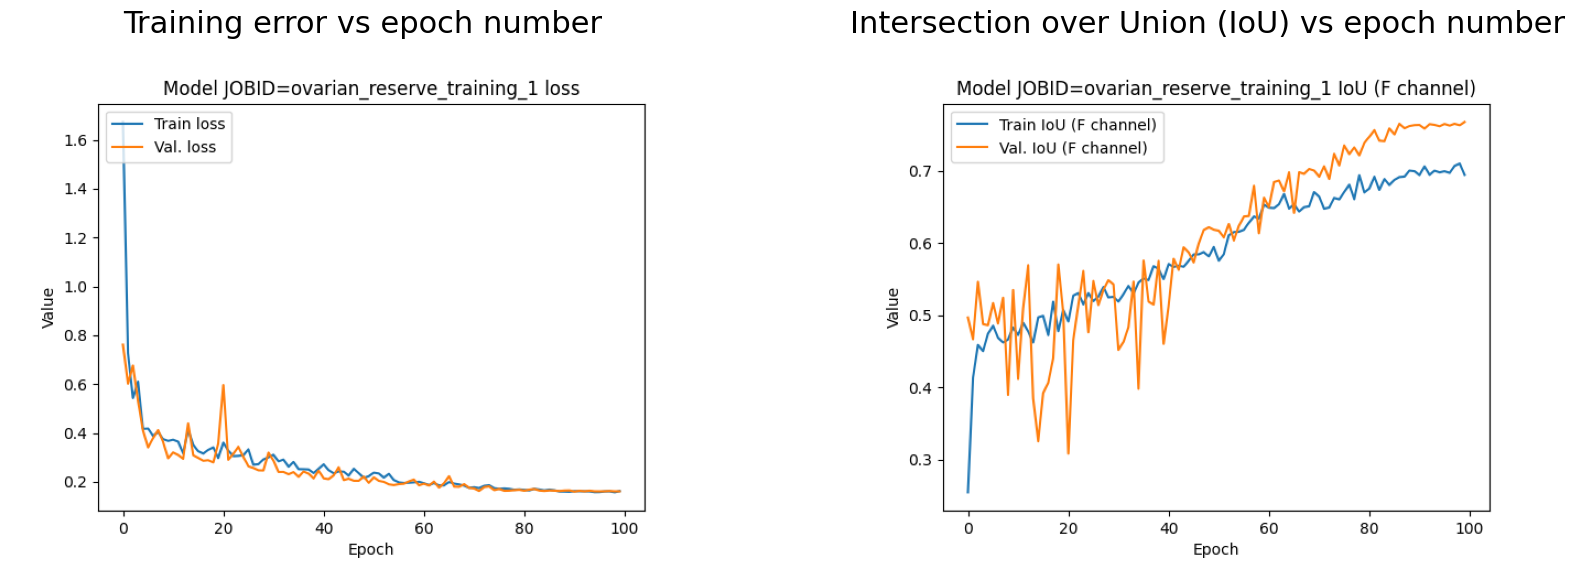

In [18]:
#@markdown ##Play the cell to show a plot of training error vs. epoch number and IoU vs epoch number
import matplotlib.pyplot as plt

loss_plot = imread( output_path + '/'+job_name+'/results/'+job_name+'_1/charts/'+job_name+'_1_loss.png' )

channel_suffix = 'F'
iou_plot = imread( output_path + '/'+job_name+'/results/'+job_name+'_1/charts/'+job_name+'_1_IoU ('+channel_suffix+' channel).png' )
fig = plt.figure( figsize = (20,10))
ax1 = plt.subplot( 1, 2, 1 )
_ = plt.imshow( loss_plot )
_ = plt.axis('off')
ax1.set_title( 'Training error vs epoch number', fontdict = {'fontsize':22})

ax2 = plt.subplot( 1, 2, 2 )
_ = plt.imshow( iou_plot )
_ = plt.axis('off')
_= ax2.set_title( 'Intersection over Union (IoU) vs epoch number', fontdict = {'fontsize':22})

## **Visualize instance segmentation results (from the validation set)**
---

In [20]:
#@markdown ###Play to visualize results from the validation set

%matplotlib inline
import matplotlib
import numpy as np
from numpy.random import randint, seed
from matplotlib import pyplot as plt
from ipywidgets import interact, fixed
import ipywidgets as widgets
from google.colab import output
output.enable_custom_widget_manager()

final_results = os.path.join(output_path, job_name, 'results', job_name + "_1")

instance_results = os.path.join(final_results, "per_image_instances")

#@markdown The current model will be applied to some validation images and results will be shown as browsable 2D stacks displaying:
#@markdown 1. The **Source image**.
#@markdown 2. Its corresponding **Ground truth** labels.
#@markdown 3. The model **Prediction** labels.
#@markdown 4. The **Overlay** between ground truth and predicted labels.


# Show a few examples to check that they have been stored correctly
ids_pred_all = sorted(next(os.walk(instance_results))[2])
ids_pred = [f for f in ids_pred_all if f.endswith('.tif')] # These are filenames of the predicted images (from validation set)

# The corresponding input and ground truth images should be loaded from the validation paths
ids_val_raw_all = sorted(next(os.walk(val_data_path))[2])
ids_val_raw = [f for f in ids_val_raw_all if f.endswith('.tif')]

ids_val_gt_all = sorted(next(os.walk(val_data_gt_path))[2])
ids_val_gt = [f for f in ids_val_gt_all if f.endswith('.tif')]

# Create dictionaries for quick lookup by filename
val_raw_map = {os.path.basename(f): os.path.join(val_data_path, f) for f in ids_val_raw}
val_gt_map = {os.path.basename(f): os.path.join(val_data_gt_path, f) for f in ids_val_gt}

# Ensure that the number of samples to show is limited by the actual number of predictions
samples_to_show = min(len(ids_pred), 3)
chosen_indices_from_preds = np.random.choice(len(ids_pred), samples_to_show, replace=False)
seed(1)

test_samples = []
test_sample_preds = []
test_sample_gt = []

# read 3D images again
for i in chosen_indices_from_preds:
    pred_filename = ids_pred[i]

    # Check if corresponding raw and gt files exist before loading
    if pred_filename in val_raw_map and pred_filename in val_gt_map:
        aux_raw = imread(val_raw_map[pred_filename])
        test_samples.append(aux_raw)

        aux_pred = imread(os.path.join(instance_results, pred_filename)).astype(np.uint16)
        test_sample_preds.append(aux_pred)

        aux_gt = imread(val_gt_map[pred_filename]).astype(np.uint16)
        test_sample_gt.append(aux_gt)
    else:
        print(f"Warning: Skipping {pred_filename} as corresponding raw or ground truth image not found in validation directories.")

# Update samples_to_show to reflect the actual number of valid triplets found
actual_samples_to_display = len(test_samples)

# create random color map
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gist_rainbow(vals))
cmap.colors[0] = [0., 0., 0., 1.] # set background to black

# function to show results in 3D within a widget
def scroll_in_z(z, j):

    plt.figure(figsize=(25,5))
    # Source
    plt.subplot(1,4,1)
    plt.axis('off')
    plt.imshow(test_samples[j][z-1], cmap='gray')
    plt.title('Source (z = ' + str(z) + ')', fontsize=15)

    # Target (Ground-truth)
    plt.subplot(1,4,2)
    plt.axis('off')
    plt.imshow(test_sample_gt[j][z-1], cmap=cmap, interpolation='nearest')
    plt.title('Ground truth (z = ' + str(z) + ')', fontsize=15)

    # Prediction
    plt.subplot(1,4,3)
    plt.axis('off')
    plt.imshow(test_sample_preds[j][z-1], cmap=cmap, interpolation='nearest')
    plt.title('Prediction (z = ' + str(z) + ')', fontsize=15)

    # Overlay
    plt.subplot(1,4,4)
    plt.axis('off')
    plt.imshow(test_sample_gt[j][z-1], cmap='Greens')
    plt.imshow(test_sample_preds[j][z-1], alpha=0.5, cmap='Purples')
    plt.title('Overlay (z = ' + str(z) + ')', fontsize=15)

    plt.show()

if actual_samples_to_display == 0:
    print("No valid image-prediction-ground truth triplets were available for visualization.")
else:
    for j in range(actual_samples_to_display):
        interact(scroll_in_z, z=widgets.IntSlider(min=1, max=test_sample_gt[j].shape[0], step=1, value=test_sample_gt[j].shape[0]//2), j=fixed(j));

interactive(children=(IntSlider(value=20, description='z', max=40, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=20, description='z', max=40, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=20, description='z', max=40, min=1), Output()), _dom_classes=('widget-in…

## **Download instance segmentation results**
---

In [21]:
#@markdown ###Play to download a zip file with all instance segmentation results in test.

from google.colab import files

!zip -q -j /content/ovarian_reserve_results.zip $instance_results/*.tif

files.download("/content/ovarian_reserve_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Download train model (weights and configuration file)**
---
If you want to **reuse the train model in the future**, you can download both the model weights and its configuration file (.YAML) by running the following cells.

In [22]:
from google.colab import files

#@markdown ###Play to download the model weights

checkpoints_path = os.path.join(output_path, job_name, 'checkpoints')

weights_filename = str( job_name ) + '_1-checkpoint-best.pth'

files.download( os.path.join( checkpoints_path, weights_filename))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
#@markdown ###Play to download the model configuration file (.YAML)

config_path = os.path.join(output_path, job_name, 'config_files')

files.download( os.path.join( config_path, yaml_file))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **How to use the trained model with new data**
---
To directly infer new data to the trained model, you can use [this notebook](https://github.com/BiaPyX/BiaPy/blob/master/notebooks/BiaPy_Inference.ipynb). It will be necessary to upload the downloaded YAML configuration file and model weights to that notebook.

## **Acknowledgments**
---
We would like to express our gratitude for the inspiration drawn from the exceptional [ZeroCostDL4Mic notebooks](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki). Specifically, we've adopted some of their metric and parameter descriptions, as well as the 3D visualization widget code present in their [U-Net 3D notebook](https://colab.research.google.com/github/HenriquesLab/ZeroCostDL4Mic/blob/master/Colab_notebooks/U-Net_3D_ZeroCostDL4Mic.ipynb). Additionally, our heartfelt thanks go out to [Estibaliz Gomez-de-Mariscal](https://scholar.google.es/citations?user=gsg-TAUAAAAJ) for her invaluable support and perceptive feedback, which significantly enhanced the quality of this notebook.
